# FIR vs IIR and Basic Filter Types

This notebook introduces basic digital filter structures and frequency-selective filtering. FIR and IIR filters are compared, followed by experiments with common filter types.

## Objective

The objectives of this notebook are to:

- Understand the basic difference between FIR and IIR filters.
- Observe how digital filters modify the frequency content of a signal.
- Understand low-pass, high-pass, band-pass, and band-stop filtering.
- Relate filter parameters to the resulting frequency response and output signal.

## Theory

A digital filter is a discrete-time system that modifies a signal according to its frequency content.

### FIR Filters

A Finite Impulse Response (FIR) filter has a finite-duration impulse response. Its output can be written as

$$
y[n] = \sum_{k=0}^{M} b_k x[n-k]
$$

where $x[n]$ is the input signal, $y[n]$ is the output signal, and $b_k$ are the filter coefficients.

FIR filters do not use feedback from previous output samples.

### IIR Filters

An Infinite Impulse Response (IIR) filter uses both previous input and previous output samples:

$$
y[n] =
\sum_{k=0}^{M} b_k x[n-k]
-
\sum_{k=1}^{N} a_k y[n-k]
$$

The feedback terms allow the impulse response to continue indefinitely.

### Basic Filter Types

A **low-pass filter** passes low-frequency components and attenuates high-frequency components.

A **high-pass filter** passes high-frequency components and attenuates low-frequency components.

A **band-pass filter** passes a selected frequency range.

A **band-stop filter** attenuates a selected frequency range while passing frequencies outside that range.

### Frequency Response

The frequency response describes how the filter changes the amplitude and phase of different frequencies.

The magnitude response is commonly represented as

$$
|H(f)|
$$

and shows which frequency components are passed or attenuated by the filter.

## Experiment 1: FIR Low-Pass Filter

We first create a signal containing two sinusoidal components at different frequencies.

A low-pass FIR filter will then be designed to preserve the lower-frequency component while attenuating the higher-frequency component.

The input and filtered signals will be examined both in the time domain and frequency domain.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Sampling parameters
fs = 1000  # Hz
duration = 1.0  # seconds

t = np.arange(0, duration, 1 / fs)

# Signal components
f1 = 50   # Hz
f2 = 200  # Hz

x = (
    np.sin(2 * np.pi * f1 * t)
    + 0.7 * np.sin(2 * np.pi * f2 * t)
)

# FIR low-pass filter
num_taps = 51
cutoff = 100  # Hz

b_fir = signal.firwin(
    numtaps=num_taps,
    cutoff=cutoff,
    fs=fs,
    window="hamming"
)

a_fir = np.array([1.0])

# Apply filter
y_fir = signal.lfilter(b_fir, a_fir, x)

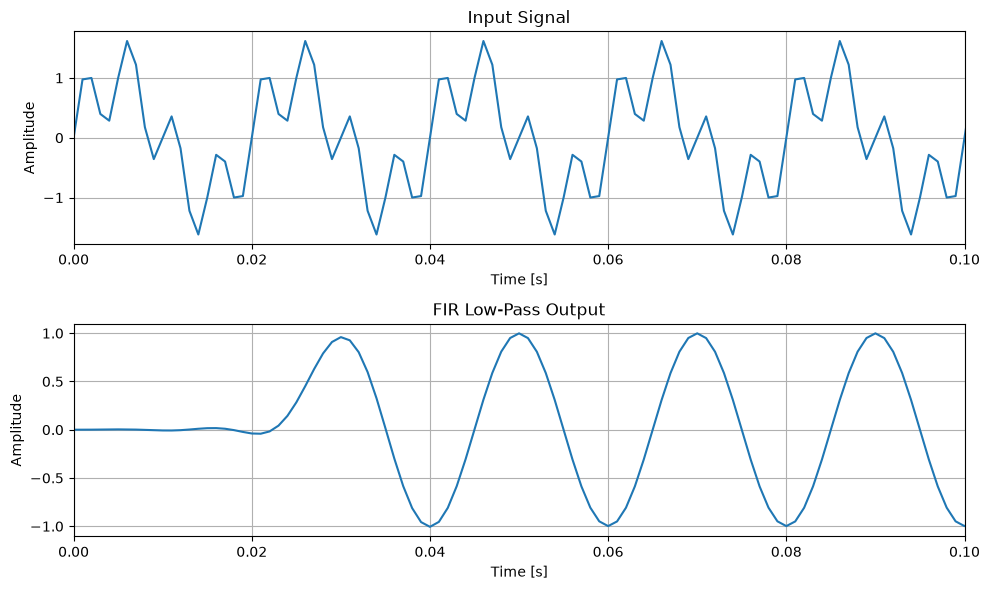

In [7]:
# Plot time-domain signals
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, x)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Input Signal")
plt.xlim(0, 0.1)
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, y_fir)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("FIR Low-Pass Output")
plt.xlim(0, 0.1)
plt.grid()

plt.tight_layout()
plt.show()

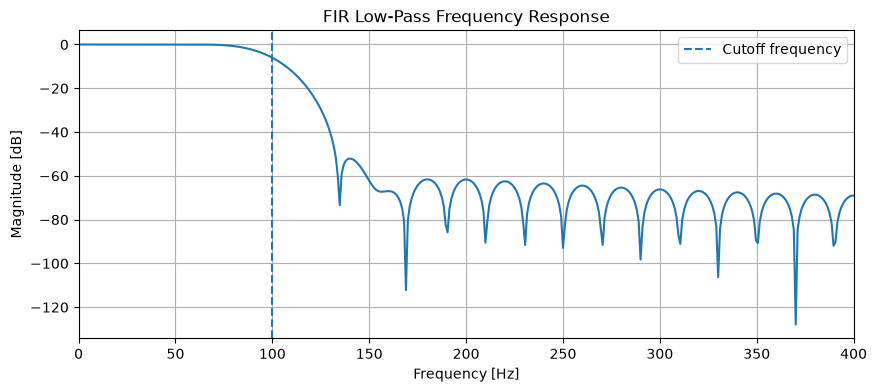

In [8]:
# Frequency response of the FIR filter
f, h = signal.freqz(b_fir, a_fir, fs=fs)

plt.figure(figsize=(10, 4))

plt.plot(f, 20 * np.log10(np.maximum(np.abs(h), 1e-10)))
plt.axvline(cutoff, linestyle="--", label="Cutoff frequency")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("FIR Low-Pass Frequency Response")
plt.xlim(0, 400)
plt.grid()
plt.legend()
plt.show()

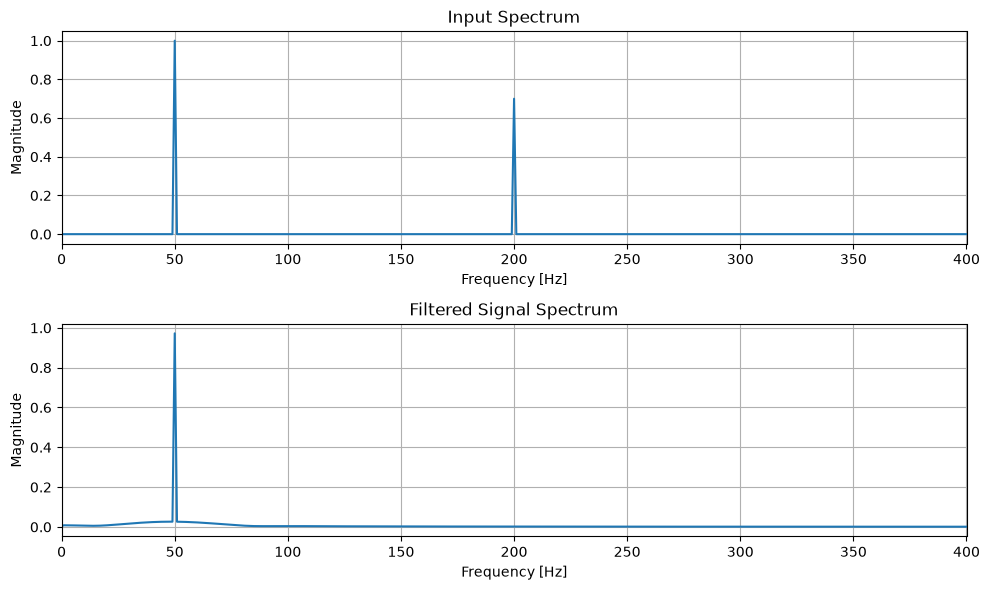

In [9]:
# Calculate magnitude spectrum
def magnitude_spectrum(x, fs):
    n = len(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(n, d=1 / fs)

    magnitude = np.abs(X) / n
    magnitude[1:-1] *= 2

    return f, magnitude


f_input, X_input = magnitude_spectrum(x, fs)
f_output, X_output = magnitude_spectrum(y_fir, fs)

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(f_input, X_input)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Input Spectrum")
plt.xlim(0, 400)
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(f_output, X_output)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Filtered Signal Spectrum")
plt.xlim(0, 400)
plt.grid()

plt.tight_layout()
plt.show()

### Observation

- 50 Hz component passed through the FIR low-pass filter.
- 200 Hz component was attenuated by the filter.
- The graph shows 200 Hz component was completely removed but other frequency components neighboring 50 Hz is still present.
- Components whose freq. are smaller than 100 Hz pass the filter but those whose freq. are bigger than 100 hz get attenuated. 100 Hz is cutoff frequency.
- Filter output delays by 0.02 s in time domain.

## Experiment 2: IIR Low-Pass Filter

Apply an IIR low-pass filter to the same input signal.

Use a low-order Butterworth filter so that the comparison focuses on the difference between FIR and IIR structures rather than high-order numerical stability.

The same cutoff frequency will be used as in Experiment 1.

In [10]:
# IIR Butterworth low-pass filter
order = 4
cutoff_iir = 100  # Hz

b_iir, a_iir = signal.butter(
    N=order,
    Wn=cutoff_iir,
    btype="lowpass",
    fs=fs
)

# Apply filter
y_iir = signal.lfilter(b_iir, a_iir, x)

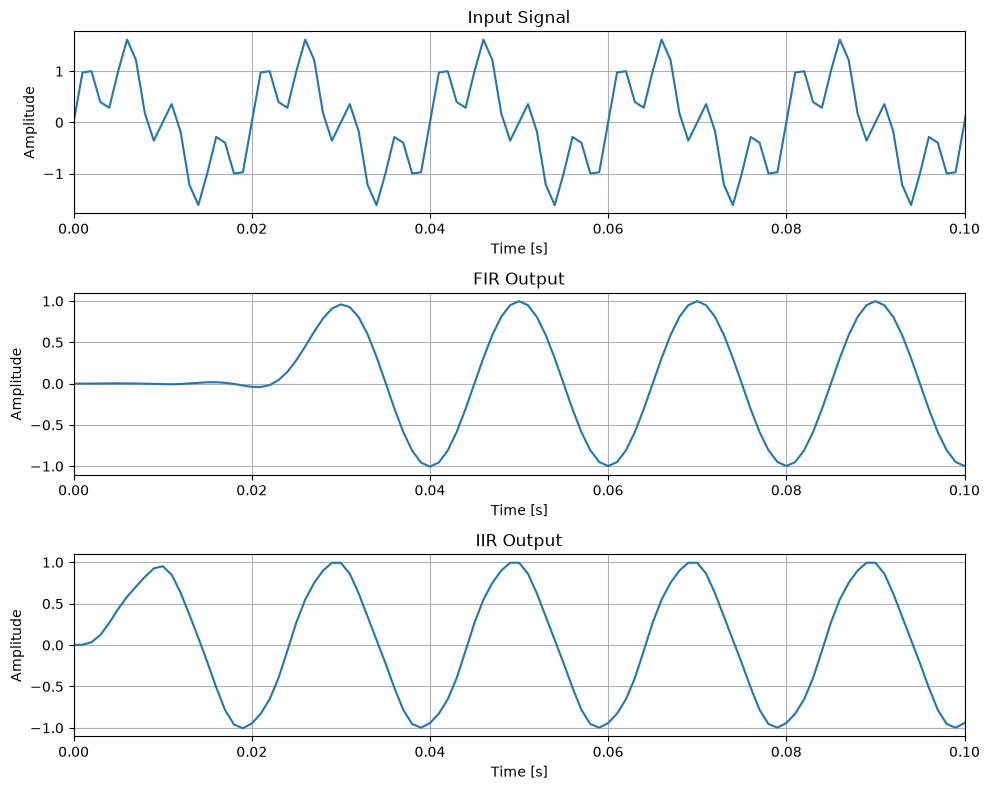

In [11]:
# Time-domain comparison
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Input Signal")
plt.xlim(0, 0.1)
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, y_fir)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("FIR Output")
plt.xlim(0, 0.1)
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, y_iir)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("IIR Output")
plt.xlim(0, 0.1)
plt.grid()

plt.tight_layout()
plt.show()

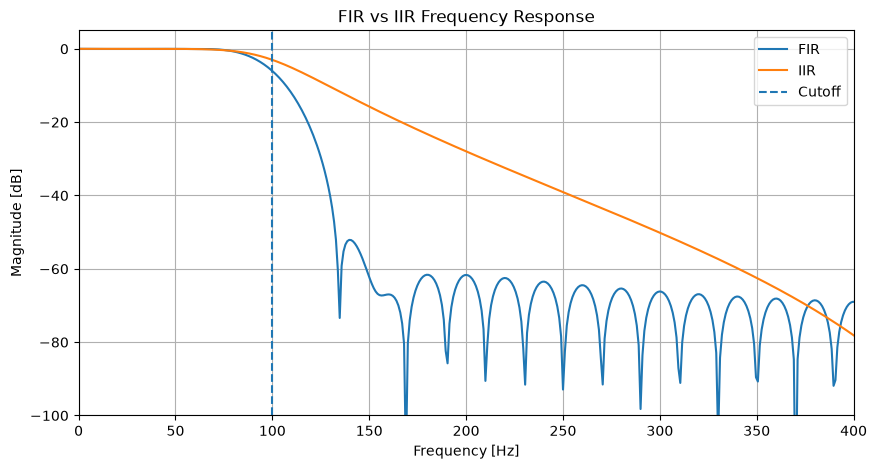

In [12]:
# Frequency response comparison
f_fir, h_fir = signal.freqz(b_fir, a_fir, fs=fs)
f_iir, h_iir = signal.freqz(b_iir, a_iir, fs=fs)

plt.figure(figsize=(10, 5))

plt.plot(
    f_fir,
    20 * np.log10(np.maximum(np.abs(h_fir), 1e-10)),
    label="FIR"
)

plt.plot(
    f_iir,
    20 * np.log10(np.maximum(np.abs(h_iir), 1e-10)),
    label="IIR"
)

plt.axvline(cutoff, linestyle="--", label="Cutoff")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("FIR vs IIR Frequency Response")
plt.xlim(0, 400)
plt.ylim(-100, 5)
plt.grid()
plt.legend()
plt.show()

In [13]:
# Compare the number of coefficients

fir_taps = 51
iir_order = 4

b_fir = signal.firwin(
    numtaps=fir_taps,
    cutoff=100,
    fs=fs,
    window="hamming"
)

b_iir, a_iir = signal.butter(
    N=iir_order,
    Wn=100,
    btype="lowpass",
    fs=fs
)

print("FIR:")
print(f"  b coefficients: {len(b_fir)}")
print(f"  Total coefficients: {len(b_fir)}")

print("\nIIR:")
print(f"  b coefficients: {len(b_iir)}")
print(f"  a coefficients: {len(a_iir)}")
print(f"  Total stored coefficients: {len(b_iir) + len(a_iir)}")
print(f"  Effective coefficients (excluding a[0]): {len(b_iir) + len(a_iir) - 1}")

FIR:
  b coefficients: 51
  Total coefficients: 51

IIR:
  b coefficients: 5
  a coefficients: 5
  Total stored coefficients: 10
  Effective coefficients (excluding a[0]): 9


### Observation

- As of the cutoff, FIR quickly attenuate the waves but in a periodic order, it attenuates some freq. more intensely.
- On the other hand, IIR attenuates slower but much more consistently and linearly.
- FIR delays the output by 0.02 s meanwhile IIR almost does not delay.
- Difference in time delay may be essential in time-critical systems and difference in attenuation may be essential in noise-sensitive systems.
- IIR has way less coefficients than that of FIR.

## Experiment 3: FIR vs IIR Filter Order

Investigate how the number of FIR taps and the IIR filter order affect the frequency response.

The goal is to see how filter complexity changes the transition between the passband and stopband.

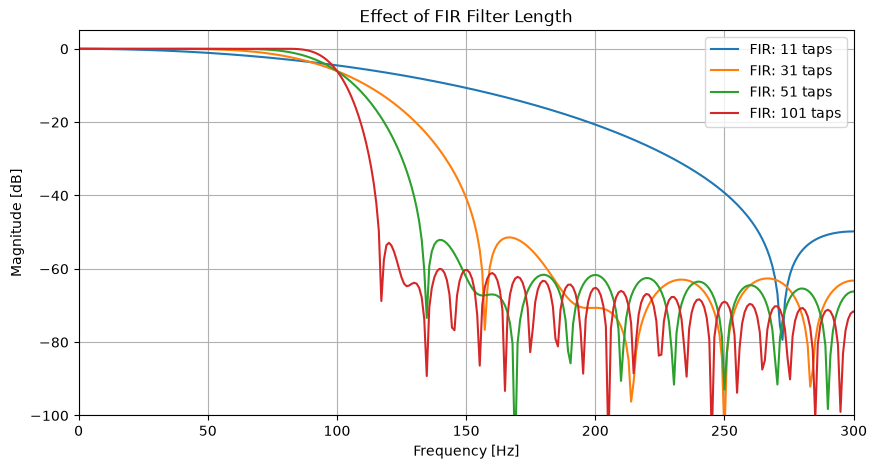

In [14]:
fir_taps_list = [11, 31, 51, 101]
iir_orders = [2, 4, 8]

plt.figure(figsize=(10, 5))

for taps in fir_taps_list:
    b = signal.firwin(
        numtaps=taps,
        cutoff=100,
        fs=fs,
        window="hamming"
    )

    f, h = signal.freqz(b, fs=fs)

    plt.plot(
        f,
        20 * np.log10(np.maximum(np.abs(h), 1e-10)),
        label=f"FIR: {taps} taps"
    )

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Effect of FIR Filter Length")
plt.xlim(0, 300)
plt.ylim(-100, 5)
plt.grid()
plt.legend()
plt.show()

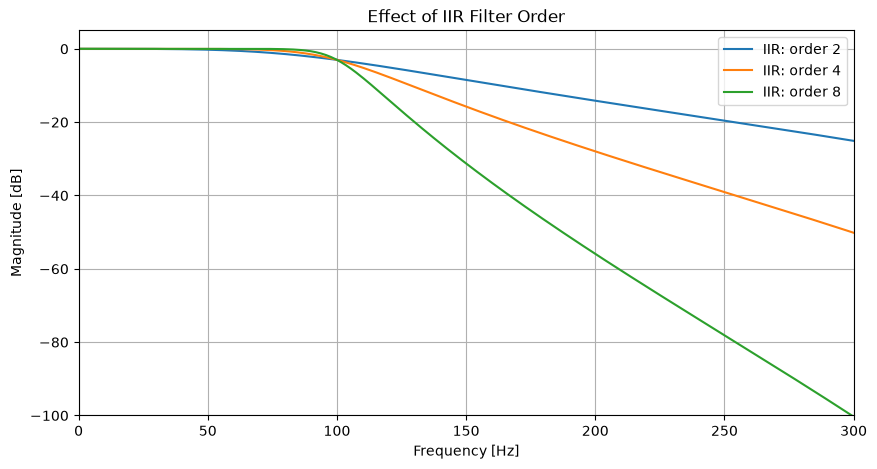

In [15]:
plt.figure(figsize=(10, 5))

for order in iir_orders:
    b, a = signal.butter(
        N=order,
        Wn=100,
        btype="lowpass",
        fs=fs
    )

    f, h = signal.freqz(b, a, fs=fs)

    plt.plot(
        f,
        20 * np.log10(np.maximum(np.abs(h), 1e-10)),
        label=f"IIR: order {order}"
    )

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Effect of IIR Filter Order")
plt.xlim(0, 300)
plt.ylim(-100, 5)
plt.grid()
plt.legend()
plt.show()

### Observation

- As FIR filter length increases, the periods delay more and get longer to response.
- As IIR order increases, angle of their curves get bigger, which means that filter attenuates more.
- IIR required much less coefficients to increase effectiveness, compared to FIR.

## Experiment 4: Low-Pass and High-Pass Filters

Use a signal containing several frequency components and apply both a low-pass and a high-pass FIR filter.

The cutoff frequency is placed between selected components so that the two filters retain different parts of the same signal.

In [16]:
# Multi-frequency input signal
frequencies = [30, 100, 250]
amplitudes = [1.0, 0.8, 0.6]

x_multi = sum(
    amplitude * np.sin(2 * np.pi * frequency * t)
    for frequency, amplitude in zip(frequencies, amplitudes)
)

# Low-pass filter
b_lp = signal.firwin(
    numtaps=51,
    cutoff=120,
    fs=fs,
    pass_zero="lowpass"
)

# High-pass filter
b_hp = signal.firwin(
    numtaps=51,
    cutoff=120,
    fs=fs,
    pass_zero="highpass"
)

y_lp = signal.lfilter(b_lp, [1.0], x_multi)
y_hp = signal.lfilter(b_hp, [1.0], x_multi)

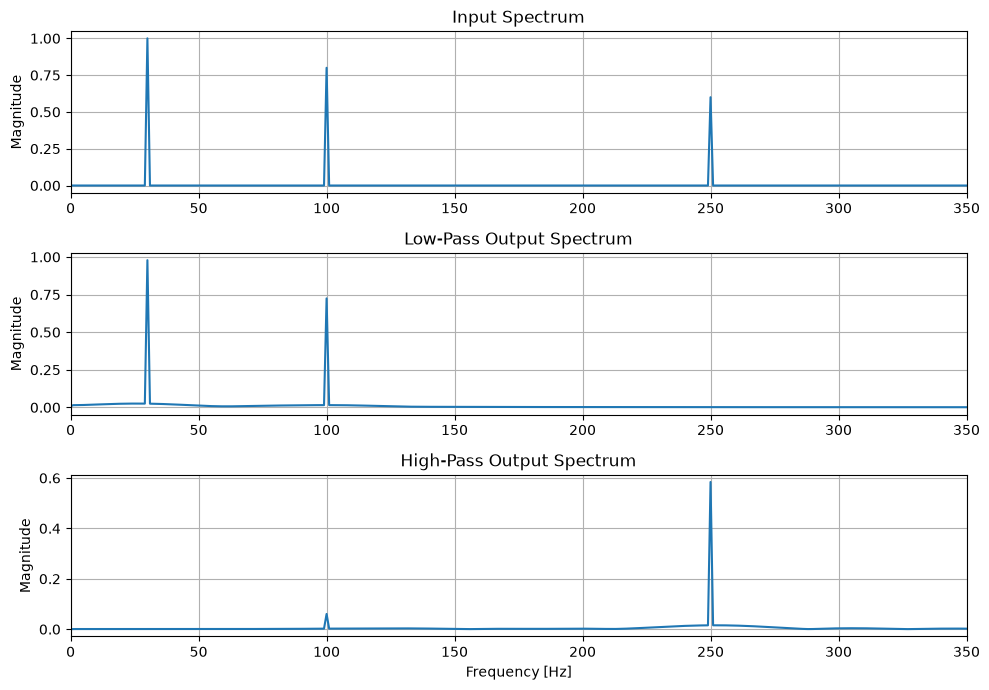

In [17]:
# Frequency-domain comparison
f_input, X_multi = magnitude_spectrum(x_multi, fs)
f_lp, X_lp = magnitude_spectrum(y_lp, fs)
f_hp, X_hp = magnitude_spectrum(y_hp, fs)

plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(f_input, X_multi)
plt.title("Input Spectrum")
plt.xlim(0, 350)
plt.ylabel("Magnitude")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(f_lp, X_lp)
plt.title("Low-Pass Output Spectrum")
plt.xlim(0, 350)
plt.ylabel("Magnitude")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(f_hp, X_hp)
plt.title("High-Pass Output Spectrum")
plt.xlim(0, 350)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid()

plt.tight_layout()
plt.show()

### Observation

- After low-pass filtering, 30 and 100 Hz components remain.
- After high-pass filtering, 250 Hz component and slight amount of 100 Hz component remain.
- 100 Hz being near the cutoff causes a small amount of it to leak through high-pass filter.
- Low-pass filter attenuates freq. bigger than 120 Hz (cutoff freq.) but high-pass filter attenuates those smaller than 120 Hz.

## Experiment 5: Band-Pass Filter

Design a FIR band-pass filter that passes only a selected frequency range.

The input contains several sinusoidal components, including components both inside and outside the selected band.

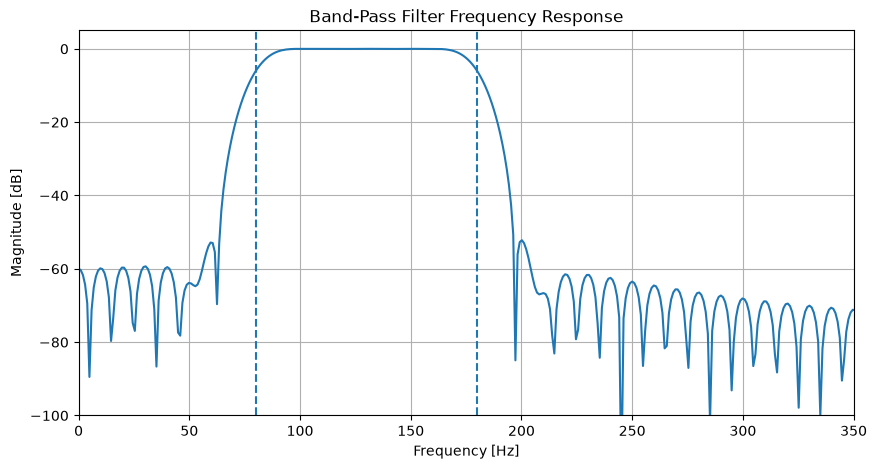

In [18]:
# Band-pass filter
band = [80, 180]

b_bp = signal.firwin(
    numtaps=101,
    cutoff=band,
    fs=fs,
    pass_zero="bandpass"
)

y_bp = signal.lfilter(b_bp, [1.0], x_multi)

# Frequency response
f_bp, h_bp = signal.freqz(b_bp, [1.0], fs=fs)

plt.figure(figsize=(10, 5))

plt.plot(
    f_bp,
    20 * np.log10(np.maximum(np.abs(h_bp), 1e-10))
)

plt.axvline(band[0], linestyle="--")
plt.axvline(band[1], linestyle="--")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Band-Pass Filter Frequency Response")
plt.xlim(0, 350)
plt.ylim(-100, 5)
plt.grid()
plt.show()

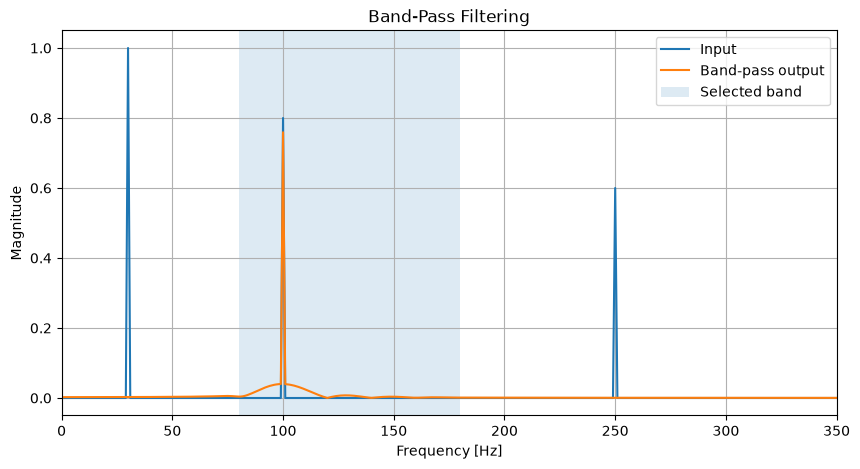

In [19]:
# Input and output spectra
f_input, X_multi = magnitude_spectrum(x_multi, fs)
f_bp_out, X_bp = magnitude_spectrum(y_bp, fs)

plt.figure(figsize=(10, 5))

plt.plot(f_input, X_multi, label="Input")
plt.plot(f_bp_out, X_bp, label="Band-pass output")

plt.axvspan(
    band[0],
    band[1],
    alpha=0.15,
    label="Selected band"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Band-Pass Filtering")
plt.xlim(0, 350)
plt.grid()
plt.legend()
plt.show()

### Observation

- Components between 80-100 Hz frequencies lie inside the passband.
- Components outside of the interval are attenuated.
- Near the lower and upper band edges, these components leak through the filter. The passband is not perfectly flat.

## Experiment 6: Band-Stop Filter

Design a FIR band-stop filter that suppresses a selected frequency range while retaining frequencies outside that range.

Use the same multi-frequency input signal so that the effect can be directly compared with the previous experiment.

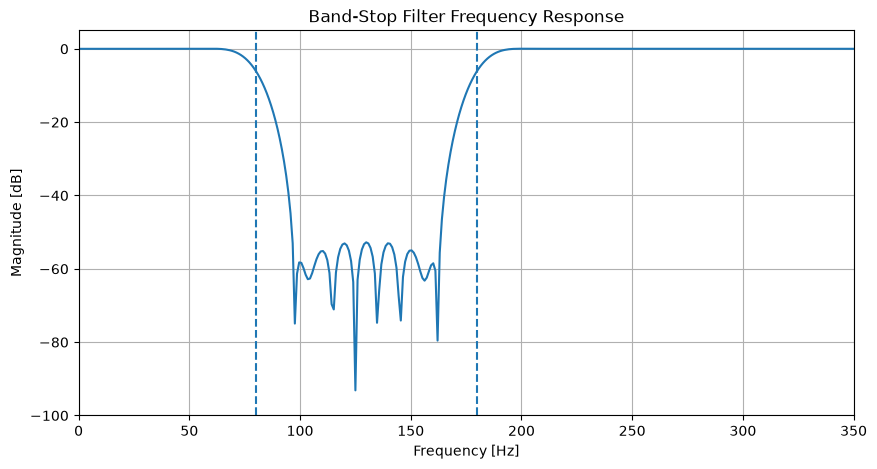

In [20]:
# Band-stop filter
stop_band = [80, 180]

b_bs = signal.firwin(
    numtaps=101,
    cutoff=stop_band,
    fs=fs,
    pass_zero="bandstop"
)

y_bs = signal.lfilter(b_bs, [1.0], x_multi)

# Frequency response
f_bs, h_bs = signal.freqz(b_bs, [1.0], fs=fs)

plt.figure(figsize=(10, 5))

plt.plot(
    f_bs,
    20 * np.log10(np.maximum(np.abs(h_bs), 1e-10))
)

plt.axvline(stop_band[0], linestyle="--")
plt.axvline(stop_band[1], linestyle="--")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Band-Stop Filter Frequency Response")
plt.xlim(0, 350)
plt.ylim(-100, 5)
plt.grid()
plt.show()

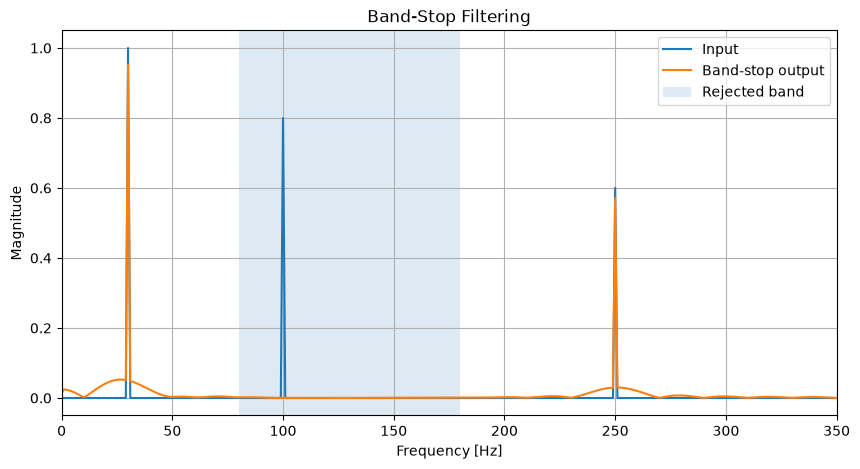

In [21]:
# Input and output spectra
f_input, X_multi = magnitude_spectrum(x_multi, fs)
f_bs_out, X_bs = magnitude_spectrum(y_bs, fs)

plt.figure(figsize=(10, 5))

plt.plot(f_input, X_multi, label="Input")
plt.plot(f_bs_out, X_bs, label="Band-stop output")

plt.axvspan(
    stop_band[0],
    stop_band[1],
    alpha=0.15,
    label="Rejected band"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Band-Stop Filtering")
plt.xlim(0, 350)
plt.grid()
plt.legend()
plt.show()

### Observation

- Frequency components inside the defined interval are attenuated.
- Components smaller than 80 Hz and bigger than 100 Hz remain outside the stopband.
- Band-stop attenuates the defined frequency band meanwhile band-pass passes the band and attenuates the rest.
- Near the two stopband edges, some boundry frequencies inside the interval manage to leak in varying amounts, correlated to their closeness to boundary frequencies.

## Key Takeaways

- Low-pass filter filters the freq. bigger than the cutoff.
- High-pass filter filters the freq. smaller than the cutoff.
- Band-pass filter filters the freq. outside the defined band.
- Band-stop filter filters the freq. inside the defined band.
- IIR requires less coefficients and more effective than FIR due to having infinite responses, unlike FIR.
- For both FIR and IIR, as coefficients increase, effectiveness to attenuate unwanted signals improve.

## Next Step

The next notebook will investigate IIR filter design using Butterworth, Chebyshev, and elliptic filters, focusing on the trade-offs between passband behavior, transition sharpness, stopband attenuation, and filter order.